# Quantization dan Komparasi YOLO26 NCNN

Notebook ini menyiapkan dan membandingkan:

1. **NCNN FP32** (baseline/tidak dikuantisasi)
2. **NCNN FP16**
3. **NCNN INT8** (pengganti integer yang didukung NCNN)

Metrik:

- `mAP50`
- `mAP50-95`
- latensi inferensi per gambar (ms)
- ukuran model

> **Catatan penting:** NCNN tidak menyediakan post-training quantization **INT16**.
> Jalur resmi integer NCNN adalah **INT8** (`ncnn2table` + `ncnn2int8`), sedangkan
> Ultralytics menyediakan ekspor NCNN FP16 melalui `half=True`. Karena itu notebook
> ini tidak memberi label INT16 pada artefak yang sebenarnya bukan INT16.

Referensi:

- https://docs.ultralytics.com/integrations/ncnn/
- https://github.com/Tencent/ncnn/wiki/quantized-int8-inference

In [1]:
from pathlib import Path
import importlib.util
import os
import platform
import shutil
import statistics
import subprocess
import sys
import time


def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-U",
            package_name or module_name,
        ])


for module, package in {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "yaml": "PyYAML",
    "cv2": "opencv-python",
    "numpy": "numpy",
}.items():
    ensure_package(module, package)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from ultralytics import YOLO

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("Torch       :", torch.__version__)
print("CUDA        :", torch.cuda.is_available())

Python      : 3.10.20
Platform    : Windows-10-10.0.26200-SP0
Torch       : 2.12.0.dev20260408+cu128
CUDA        : True


## Konfigurasi

Semua varian harus diuji pada perangkat, jumlah thread, ukuran input, dan dataset
yang sama. Untuk hasil Raspberry Pi 5, jalankan seluruh bagian evaluasi langsung
di Raspberry Pi 5.

In [2]:
PROJECT_ROOT = Path(".").resolve()
TRAIN_DIR = PROJECT_ROOT / "runs/detect/runs/train/yolo26_lele-2"
WEIGHTS = TRAIN_DIR / "weights/best.pt"
EXISTING_NCNN = TRAIN_DIR / "weights/yolo26_ncnn_model"
DATA_YAML = PROJECT_ROOT / "data.yaml"
OUTPUT_ROOT = TRAIN_DIR / "weights/quantized_ncnn"

# Nama direktori harus mengandung "ncnn_model" agar Ultralytics mengenalinya sebagai NCNN
FP32_DIR = OUTPUT_ROOT / "yolo26_ncnn_model_fp32"
FP16_DIR = OUTPUT_ROOT / "yolo26_ncnn_model_fp16"
INT8_DIR = OUTPUT_ROOT / "yolo26_ncnn_model_int8"

IMG_SIZE = 640
SPLIT = "test"
DEVICE = "cpu"
THREADS = max(1, min(4, os.cpu_count() or 1))
WARMUP_IMAGES = 10
BENCHMARK_REPEATS = 3
RUN_INT8 = True
CALIBRATION_LIMIT = 500

for required in (WEIGHTS, DATA_YAML):
    if not required.exists():
        raise FileNotFoundError(required)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(THREADS)

# Migrasi folder lama ke nama baru jika perlu
_migrations = {
    "yolo26_ncnn_fp32": FP32_DIR,
    "yolo26_ncnn_fp16": FP16_DIR,
    "yolo26_ncnn_int8": INT8_DIR,
    "best_ncnn_model_int8": INT8_DIR,
}
for old_name, new_dir in _migrations.items():
    old_dir = OUTPUT_ROOT / old_name
    if old_dir.exists() and not new_dir.exists():
        shutil.copytree(old_dir, new_dir)
        print(f"Migrasi: {old_name} → {new_dir.name}")

print("weights :", WEIGHTS)
print("data    :", DATA_YAML)
print("threads :", THREADS)
print("FP32_DIR:", FP32_DIR)
print("FP16_DIR:", FP16_DIR)
print("INT8_DIR:", INT8_DIR)


Migrasi: yolo26_ncnn_fp32 → yolo26_ncnn_model_fp32
Migrasi: yolo26_ncnn_fp16 → yolo26_ncnn_model_fp16
Migrasi: best_ncnn_model_int8 → yolo26_ncnn_model_int8
weights : D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\best.pt
data    : D:\Kuliah\Skripsi\model-dataset-2-kelas\data.yaml
threads : 4
FP32_DIR: D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp32
FP16_DIR: D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp16
INT8_DIR: D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_int8


## Ekspor FP32 dan FP16

Folder hasil ekspor Ultralytics langsung dipindahkan ke nama varian yang tetap.
Baseline yang sudah ada akan dipakai terlebih dahulu agar tidak mengubah artefak
asli.

In [3]:
def is_ncnn_model(model_dir):
    model_dir = Path(model_dir)
    return (
        (model_dir / "model.ncnn.param").exists()
        and (model_dir / "model.ncnn.bin").exists()
    )


def copy_ncnn_model(source, destination):
    source, destination = Path(source), Path(destination)
    if destination.exists():
        shutil.rmtree(destination)
    shutil.copytree(source, destination)
    return destination


def export_ncnn_variant(half, destination):
    destination = Path(destination)
    if is_ncnn_model(destination):
        print("Sudah tersedia:", destination)
        return destination

    model = YOLO(str(WEIGHTS))
    exported = Path(model.export(
        format="ncnn",
        imgsz=IMG_SIZE,
        half=half,
        batch=1,
        device="cpu",
    )).resolve()
    if not is_ncnn_model(exported):
        raise RuntimeError(f"Ekspor NCNN tidak lengkap: {exported}")
    copy_ncnn_model(exported, destination)
    print("Dibuat:", destination)
    return destination


if not is_ncnn_model(FP32_DIR):
    if is_ncnn_model(EXISTING_NCNN):
        copy_ncnn_model(EXISTING_NCNN, FP32_DIR)
        print("Baseline disalin dari:", EXISTING_NCNN)
    else:
        export_ncnn_variant(False, FP32_DIR)

export_ncnn_variant(True, FP16_DIR)

Sudah tersedia: D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp16


WindowsPath('D:/Kuliah/Skripsi/model-dataset-2-kelas/runs/detect/runs/train/yolo26_lele-2/weights/quantized_ncnn/yolo26_ncnn_model_fp16')

## Quantization Integer NCNN

INT16 tidak didukung oleh tool quantization NCNN. Cell berikut membuat **INT8**
dengan alur resmi:

1. membuat tensor kalibrasi menggunakan letterbox dan normalisasi YOLO,
2. menjalankan `ncnn2table`,
3. menjalankan `ncnn2int8`.

Letakkan executable `ncnn2table` dan `ncnn2int8` di `PATH`, atau isi path manual
pada variabel di bawah. Di Linux/Raspberry Pi, tool ini biasanya diperoleh dari
hasil build repository Tencent/ncnn dengan `NCNN_BUILD_TOOLS=ON`.

In [4]:
import platform
import sys

IS_WINDOWS = platform.system().lower() == "windows"

# Path tool NCNN di WSL (edit sesuai lokasi build Anda)
WSL_NCNN2TABLE = "/home/troy/ncnn/build/tools/quantize/ncnn2table"
WSL_NCNN2INT8  = "/home/troy/ncnn/build/tools/quantize/ncnn2int8"

# Sumber FP32 untuk kalibrasi INT8 (model asli, bukan salinan)
_NCNN_SOURCE_DIR = TRAIN_DIR / "weights/best_ncnn_model"


# --- helpers path ---

def to_wsl_path(path):
    path = Path(path).resolve()
    if not IS_WINDOWS:
        return str(path)
    s = str(path)
    return f"/mnt/{s[0].lower()}{s[2:].replace(chr(92), '/')}"


def ncnn_arg(arg):
    s = str(arg)
    if not IS_WINDOWS:
        return s
    if s.startswith(("shape=", "thread=", "method=", "type=", "mean=", "norm=", "pixel=")):
        return s
    return to_wsl_path(s)


def ncnn_command(tool_wsl_path, args):
    if IS_WINDOWS:
        return ["wsl", tool_wsl_path] + [ncnn_arg(a) for a in args]
    return [tool_wsl_path] + [str(a) for a in args]


# --- cek tool ---

def check_ncnn_tools():
    if IS_WINDOWS:
        ok_table = subprocess.run(["wsl", "test", "-x", WSL_NCNN2TABLE], check=False).returncode == 0
        ok_int8  = subprocess.run(["wsl", "test", "-x", WSL_NCNN2INT8],  check=False).returncode == 0
        if not ok_table:
            print(f"[WARN] ncnn2table tidak ditemukan: {WSL_NCNN2TABLE}")
        if not ok_int8:
            print(f"[WARN] ncnn2int8 tidak ditemukan: {WSL_NCNN2INT8}")
        return ok_table and ok_int8
    return Path(WSL_NCNN2TABLE).exists() and Path(WSL_NCNN2INT8).exists()


# --- dataset ---

def resolve_dataset_path(data_yaml, split):
    config = yaml.safe_load(Path(data_yaml).read_text(encoding="utf-8"))
    yaml_dir = Path(data_yaml).resolve().parent
    root = Path(config.get("path", "."))
    if not root.is_absolute():
        root = (yaml_dir / root).resolve()
    value = config[split]
    path = Path(value)
    return path if path.is_absolute() else (root / path).resolve()


def make_calibration_list(image_dir, output_dir, limit=500):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(
        p.resolve() for p in Path(image_dir).iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    )[:limit]

    if not images:
        raise FileNotFoundError(f"Tidak ada gambar kalibrasi di {image_dir}")

    if IS_WINDOWS:
        path_strs = [to_wsl_path(p) for p in images]
    else:
        path_strs = [str(p) for p in images]

    list_path = output_dir / "calibration_images.txt"
    list_path.write_text("\n".join(path_strs), encoding="utf-8")
    print(f"  {len(path_strs)} gambar, contoh: {path_strs[0]}")
    return list_path, len(path_strs)


# --- subprocess wrapper ---

def run_command(command, label):
    print(f"\n{label}")
    print(" ".join(str(c) for c in command))
    sys.stdout.flush()
    result = subprocess.run(command, check=False)
    if result.returncode != 0:
        raise subprocess.CalledProcessError(result.returncode, command)
    return result


# --- quantization INT8 ---

def run_int8_quantization():
    if not RUN_INT8:
        print("INT8 dilewati (RUN_INT8=False)")
        return False

    if not check_ncnn_tools():
        print("ncnn2table / ncnn2int8 tidak ditemukan di WSL.")
        return False

    if not is_ncnn_model(_NCNN_SOURCE_DIR):
        print("Model FP32 sumber tidak ditemukan di:", _NCNN_SOURCE_DIR)
        return False

    calibration_dir = OUTPUT_ROOT / "calibration"
    train_images    = resolve_dataset_path(DATA_YAML, "train")

    print("Membuat daftar kalibrasi...")
    list_path, count = make_calibration_list(train_images, calibration_dir, CALIBRATION_LIMIT)

    table_path = calibration_dir / "yolo26.table"
    INT8_DIR.mkdir(parents=True, exist_ok=True)

    fp32_param = _NCNN_SOURCE_DIR / "model.ncnn.param"
    fp32_bin   = _NCNN_SOURCE_DIR / "model.ncnn.bin"
    int8_param = INT8_DIR / "model.ncnn.param"
    int8_bin   = INT8_DIR / "model.ncnn.bin"

    table_cmd = ncnn_command(WSL_NCNN2TABLE, [
        fp32_param, fp32_bin,
        list_path, table_path,
        "mean=[0,0,0]",
        "norm=[0.00392157,0.00392157,0.00392157]",
        f"shape=[{IMG_SIZE},{IMG_SIZE},3]",
        "pixel=BGR",
        f"thread={THREADS}",
        "method=kl",
        "type=0",
    ])

    int8_cmd = ncnn_command(WSL_NCNN2INT8, [
        fp32_param, fp32_bin,
        int8_param, int8_bin,
        table_path,
    ])

    print(f"\nKalibrasi dengan {count} gambar")
    run_command(table_cmd, "ncnn2table")
    run_command(int8_cmd,  "ncnn2int8")

    for name in ("metadata.yaml", "model_ncnn.py"):
        src = _NCNN_SOURCE_DIR / name
        if src.exists():
            shutil.copy2(src, INT8_DIR / name)

    return is_ncnn_model(INT8_DIR)


int8_ready = is_ncnn_model(INT8_DIR) or run_int8_quantization()
print("\nINT8 ready :", int8_ready)
print("INT8 folder:", INT8_DIR)



INT8 ready : True
INT8 folder: D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_int8


## Validasi mAP dan benchmark latensi

`model.val()` digunakan untuk mAP agar evaluator konsisten dengan Ultralytics.
Latensi dihitung terpisah dari wall-clock `predict()` per gambar setelah warm-up.
I/O pembacaan daftar file tidak dihitung, tetapi preprocessing, inferensi, dan
postprocessing Ultralytics termasuk dalam pengukuran.

In [5]:
def collect_images(data_yaml, split):
    image_source = resolve_dataset_path(data_yaml, split)
    if image_source.is_file() and image_source.suffix.lower() == ".txt":
        images = [
            Path(line.strip())
            for line in image_source.read_text(encoding="utf-8").splitlines()
            if line.strip()
        ]
    else:
        images = sorted(
            p for p in image_source.rglob("*")
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
        )
    if not images:
        raise FileNotFoundError(f"Tidak ada gambar untuk split={split}: {image_source}")
    return images


def model_size_mb(model_dir):
    return sum(
        path.stat().st_size for path in Path(model_dir).rglob("*")
        if path.is_file()
    ) / (1024 ** 2)


def benchmark_latency(model, image_paths):
    warmup = image_paths[:min(WARMUP_IMAGES, len(image_paths))]
    for path in warmup:
        model.predict(
            source=str(path), imgsz=IMG_SIZE, device=DEVICE,
            verbose=False, save=False,
        )

    repeat_means = []
    all_times = []
    for _ in range(BENCHMARK_REPEATS):
        times = []
        for path in image_paths:
            start = time.perf_counter()
            model.predict(
                source=str(path), imgsz=IMG_SIZE, device=DEVICE,
                verbose=False, save=False,
            )
            times.append((time.perf_counter() - start) * 1000.0)
        repeat_means.append(statistics.mean(times))
        all_times.extend(times)
    return {
        "latency_ms": statistics.mean(repeat_means),
        "latency_std_ms": statistics.pstdev(all_times),
        "fps": 1000.0 / statistics.mean(repeat_means),
    }


def evaluate_variant(name, model_dir, image_paths):
    print(f"\n{'='*50}")
    print(f"Evaluasi: {name}")
    print(f"  path : {model_dir}")

    row = {
        "model": name,
        "path": str(model_dir),
        "status": "missing",
        "mAP50": np.nan,
        "mAP50-95": np.nan,
        "latency_ms": np.nan,
        "latency_std_ms": np.nan,
        "fps": np.nan,
        "size_mb": np.nan,
        "images": len(image_paths),
    }
    if not is_ncnn_model(model_dir):
        print("  [SKIP] model tidak ditemukan")
        return row

    try:
        model = YOLO(str(model_dir), task="detect")
        metrics = model.val(
            data=str(DATA_YAML),
            split=SPLIT,
            imgsz=IMG_SIZE,
            batch=1,
            device=DEVICE,
            half=False,   # CPU tidak mendukung FP16 PyTorch; NCNN menangani FP16 secara internal
            plots=False,
            verbose=False,
        )
        latency = benchmark_latency(model, image_paths)
        row.update({
            "status": "ok",
            "mAP50": float(metrics.box.map50),
            "mAP50-95": float(metrics.box.map),
            "size_mb": model_size_mb(model_dir),
            **latency,
        })
        print(f"  mAP50={row['mAP50']:.4f}  latency={row['latency_ms']:.1f}ms")
    except Exception as exc:
        row["status"] = "error"
        row["error"] = repr(exc)
        print(f"  [ERROR] {exc}")

    return row


test_images = collect_images(DATA_YAML, SPLIT)

variants = {
    "NCNN FP32": FP32_DIR,
    "NCNN FP16": FP16_DIR,
    "NCNN INT8": INT8_DIR,
}

rows = [
    evaluate_variant(name, model_dir, test_images)
    for name, model_dir in variants.items()
]
results_df = pd.DataFrame(rows)
results_df



Evaluasi: NCNN FP32
  path : D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp32
Ultralytics 8.4.51  Python-3.10.20 torch-2.12.0.dev20260408+cu128 CPU (Intel Core i7-14700HX)
Loading D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp32 for NCNN inference...


Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access  (ping: 0.00.0 ms, read: 409.8126.2 MB/s, size: 19.4 KB)
val: Scanning D:\Kuliah\Skripsi\model-dataset-2-kelas\dataset_split\test\labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144  0.0s
val: D:\Kuliah\Skripsi\model-dataset-2-kelas\dataset_split\test\images\lele 6-1_000049_jpg.rf.mAKsYMCuWsZHOjl0OzWc.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 144/144 19.3it/s 7.4s0.1s
                   all        144        144      0.998          1      0.995      0.876
Speed: 0.4ms preprocess, 44.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Loading D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\detect\runs\train\yolo26_lele-2\weights\quantized_ncnn\yolo26_ncnn_model_fp32 for NCNN inference...
  mAP50=0.9950  latency=47.7ms

Evaluasi: NCNN FP16
  path : D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\d

,model,path,status,mAP50,mAP50-95,latency_ms,latency_std_ms,fps,size_mb,images
0,NCNN FP32,D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\d...,ok,0.995000,0.875786,47.713999,4.869729,20.958210,9.212519,144
1,NCNN FP16,D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\d...,ok,0.995000,0.876403,43.967569,4.119416,22.744036,4.698335,144
2,NCNN INT8,D:\Kuliah\Skripsi\model-dataset-2-kelas\runs\d...,ok,0.651664,0.393834,35.120722,3.167258,28.473219,2.441729,144


Saved: D:\Kuliah\Skripsi\model-dataset-2-kelas\compare_yolo26_ncnn_quantization.csv


,model,mAP50,mAP50-95,latency_ms,latency_std_ms,fps,size_mb
0,NCNN FP32,0.9950,0.8758,47.7140,4.8697,20.9582,9.2125
1,NCNN FP16,0.9950,0.8764,43.9676,4.1194,22.7440,4.6983
2,NCNN INT8,0.6517,0.3938,35.1207,3.1673,28.4732,2.4417


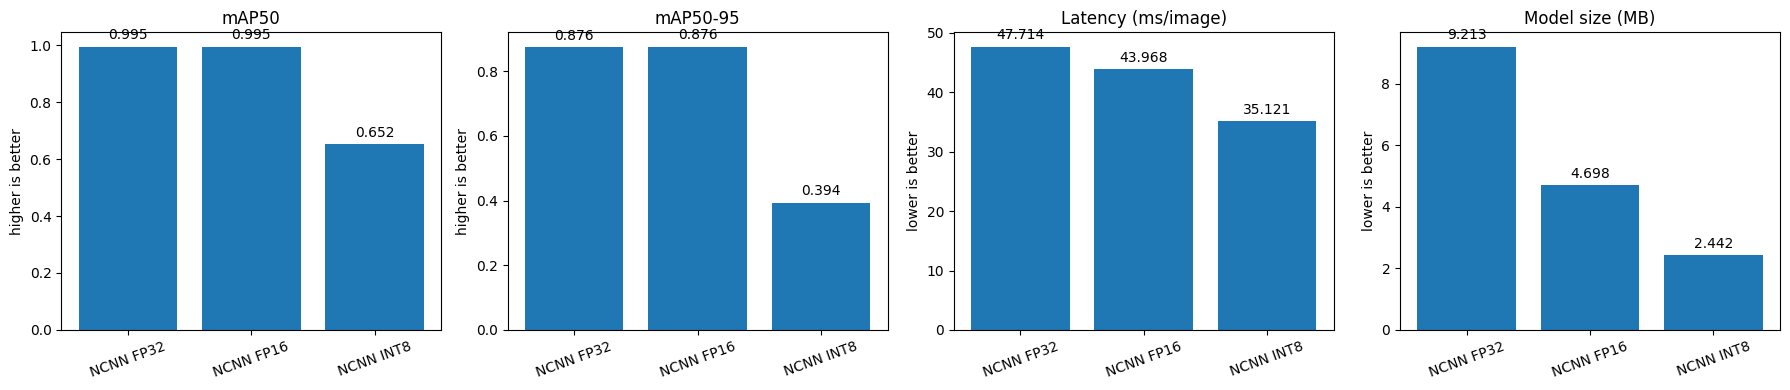

In [6]:
RESULT_CSV = PROJECT_ROOT / "compare_yolo26_ncnn_quantization.csv"
results_df.to_csv(RESULT_CSV, index=False)
print("Saved:", RESULT_CSV)

ok_df = results_df[results_df["status"] == "ok"].copy()
if ok_df.empty:
    print("Belum ada model yang berhasil dievaluasi.")
else:
    display(
        ok_df[[
            "model", "mAP50", "mAP50-95", "latency_ms",
            "latency_std_ms", "fps", "size_mb",
        ]].round(4)
    )

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    plots = [
        ("mAP50", "mAP50", True),
        ("mAP50-95", "mAP50-95", True),
        ("latency_ms", "Latency (ms/image)", False),
        ("size_mb", "Model size (MB)", False),
    ]
    for axis, (column, title, higher_is_better) in zip(axes, plots):
        bars = axis.bar(ok_df["model"], ok_df[column])
        axis.set_title(title)
        axis.tick_params(axis="x", rotation=20)
        axis.set_ylabel("higher is better" if higher_is_better else "lower is better")
        axis.bar_label(bars, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()

## Interpretasi

- Gunakan mAP untuk melihat dampak perubahan presisi terhadap akurasi.
- Gunakan latensi hasil perangkat target; hasil Windows/PC tidak mewakili
  Raspberry Pi 5.
- FP16 belum tentu lebih cepat pada semua CPU. Keuntungannya bergantung pada
  dukungan instruksi dan implementasi perangkat.
- INT8 biasanya paling kecil, tetapi kualitasnya sangat dipengaruhi jumlah dan
  representativitas gambar kalibrasi.
- Jika baris INT8 berstatus `missing`, pasang tool NCNN quantization lalu jalankan
  ulang bagian **Quantization Integer NCNN** dan evaluasi.